#***IE406 Machine Learning Lab 1***
202301090 - Jhil Patel

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [7]:
## Loading Data set

data = fetch_california_housing()

X=data.data
y=data.target

print("Feature shape : ",X.shape)
print("Target shape : ",y.shape)

Feature shape :  (20640, 8)
Target shape :  (20640,)


In [8]:
# knowing the features

print(data.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
# knowing the target

print(data.target_names)

['MedHouseVal']


In [10]:
# Split the data using random seed

np.random.seed(9432)

#***Task 1: Dataset Preparation***

In [11]:
n_samples = X.shape[0]

indices = np.random.permutation(n_samples) # Numpy Shuffling

train_end = int(0.60 * n_samples)
val_end = int(0.80 * n_samples)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Train shape : ",X_train.shape)
print("Validation shape : ",X_val.shape)
print("Test shape : ",X_test.shape)

Train shape :  (12384, 8)
Validation shape :  (4128, 8)
Test shape :  (4128, 8)


In [12]:
#Feature Normalization

X_mean = np.mean(X_train,axis=0)
X_std = np.std(X_train,axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

In [13]:
#Target Normalization

y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [14]:
#Bias Column

X_train_final = np.column_stack(
    (X_train_norm, np.ones(X_train_norm.shape[0]))
)

X_val_final = np.column_stack(
    (X_val_norm, np.ones(X_val_norm.shape[0]))
)

X_test_final = np.column_stack(
    (X_test_norm, np.ones(X_test_norm.shape[0]))
)

#***Task 2: Implement Mini-Batch Gradient Descent***

In [15]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

def compute_gradient(X_batch, y_batch, weights):
    predictions = X_batch @ weights
    errors = predictions - y_batch

    gradient = (2 / X_batch.shape[0]) * (X_batch.T @ errors)

    return gradient

def train_model(X_train, y_train, X_val, y_val,
                learning_rate, batch_size,
                max_epochs=1000, patience=100):

    n_samples = X_train.shape[0]
    n_features = X_train.shape[1]

    # Initialize weights with zeros
    weights = np.zeros(n_features)

    best_weights = weights.copy()
    best_val_mse = np.inf
    best_epoch = 0

    train_losses = []
    val_losses = []

    epochs_without_improvement = 0

    # Use the same starting random state for reproducibility
    np.random.seed(9432)

    for epoch in range(max_epochs):

        # Shuffle training data at the beginning of every epoch
        indices = np.random.permutation(n_samples)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        weighted_loss_sum = 0
        samples_seen = 0

        # Mini-batch updates
        for start in range(0, n_samples, batch_size):

            end = min(start + batch_size, n_samples)

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            batch_size_actual = X_batch.shape[0]

            # Predictions
            predictions = X_batch @ weights

            # Batch MSE
            batch_loss = np.mean(
                (predictions - y_batch) ** 2
            )

            # Gradient
            errors = predictions - y_batch

            gradient = (
                2 / batch_size_actual
            ) * (X_batch.T @ errors)

            # Gradient descent update
            weights = weights - learning_rate * gradient

            # Accumulate weighted loss
            weighted_loss_sum += batch_loss * batch_size_actual
            samples_seen += batch_size_actual

        # Sample-weighted average training MSE
        epoch_train_mse = weighted_loss_sum / samples_seen

        # Validation MSE
        val_predictions = X_val @ weights

        epoch_val_mse = np.mean(
            (val_predictions - y_val) ** 2
        )

        train_losses.append(epoch_train_mse)
        val_losses.append(epoch_val_mse)

        # Early stopping
        if epoch_val_mse < best_val_mse:

            best_val_mse = epoch_val_mse
            best_weights = weights.copy()
            best_epoch = epoch + 1

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return (
        best_weights,
        np.array(train_losses),
        np.array(val_losses),
        best_epoch
    )

In [16]:
learning_rates = [
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10
]

#***Task 3: Effect of Learning Rate***

In [17]:
lr_results = {}

for lr in learning_rates:

    weights, train_loss, val_loss, best_epoch = train_model(
        X_train_final,
        y_train_norm,
        X_val_final,
        y_val_norm,
        learning_rate=lr,
        batch_size=128
    )

    lr_results[lr] = {
        "weights": weights,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "best_val_mse": np.min(val_loss)
    }

/tmp/ipykernel_2957/1477667093.py:84: RuntimeWarning: overflow encountered in square
  (val_predictions - y_val) ** 2
/tmp/ipykernel_2957/1477667093.py:60: RuntimeWarning: overflow encountered in square
  (predictions - y_batch) ** 2
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2957/1477667093.py:68: RuntimeWarning: overflow encountered in matmul
  ) * (X_batch.T @ errors)
/tmp/ipykernel_2957/1477667093.py:56: RuntimeWarning: invalid value encountered in matmul
  predictions = X_batch @ weights
/tmp/ipykernel_2957/1477667093.py:68: RuntimeWarning: invalid value encountered in matmul
  ) * (X_batch.T @ errors)


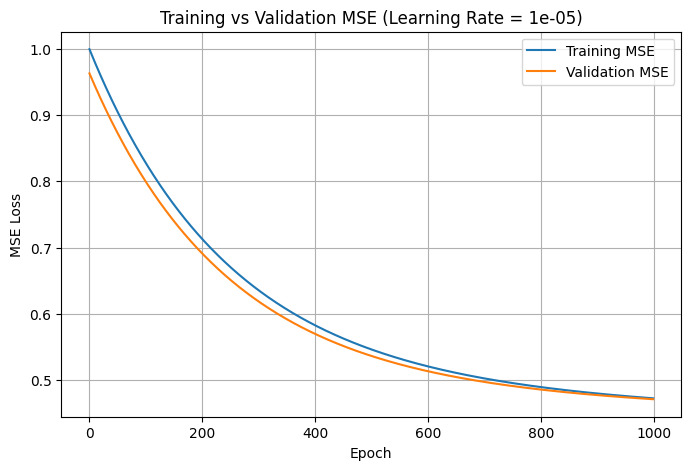

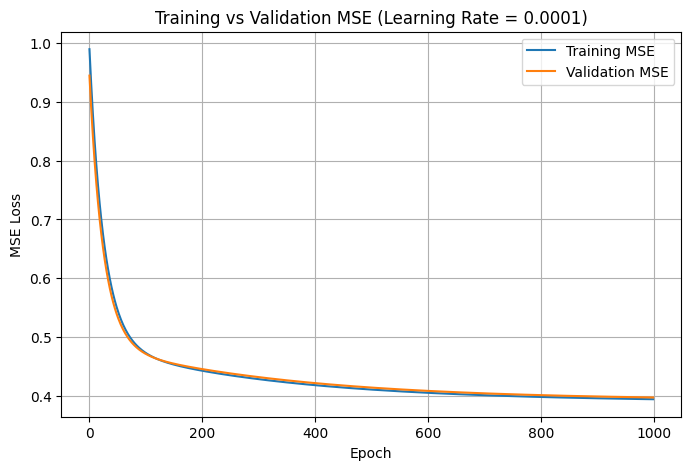

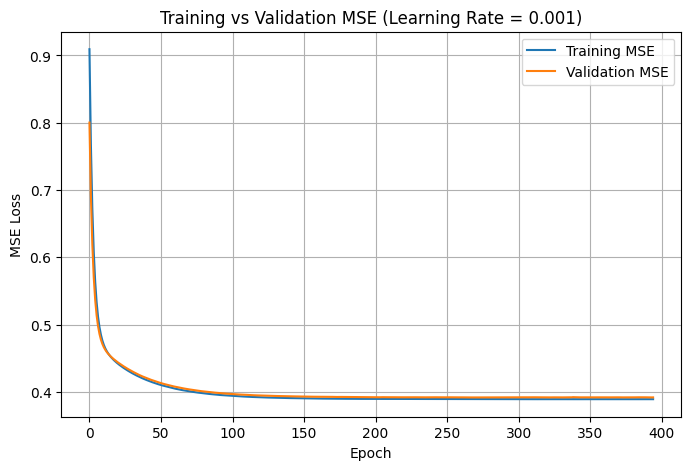

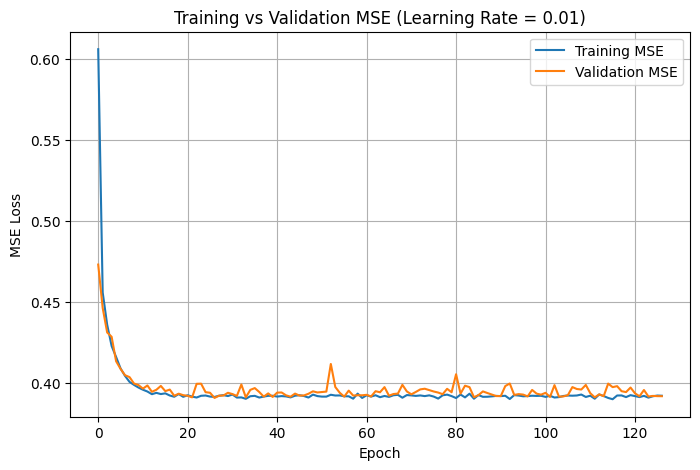

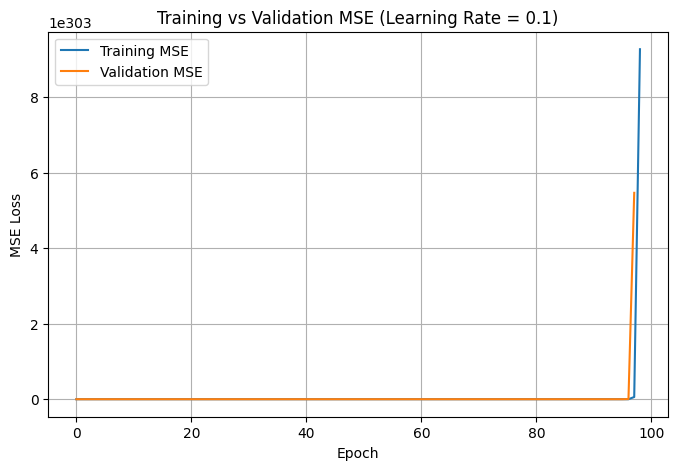

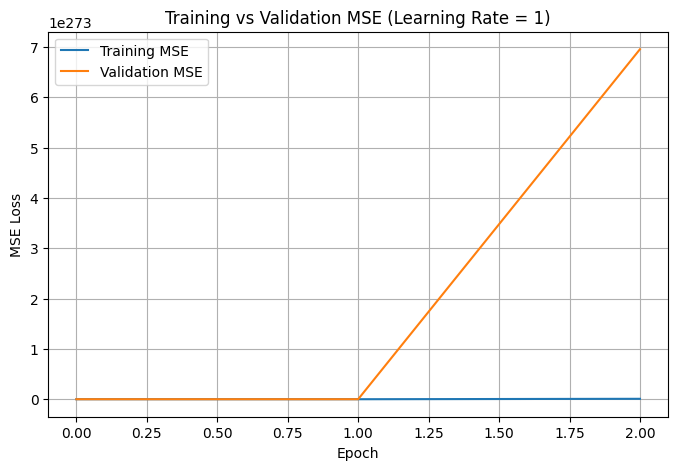

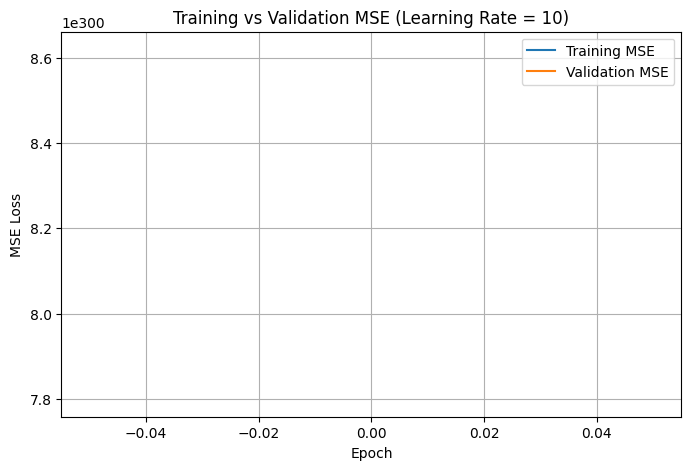

In [18]:
for lr in learning_rates:

    result = lr_results[lr]

    plt.figure(figsize=(8, 5))

    plt.plot(
        result["train_loss"],
        label="Training MSE"
    )

    plt.plot(
        result["val_loss"],
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"Training vs Validation MSE (Learning Rate = {lr})"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
best_lr = min(
    learning_rates,
    key=lambda lr: lr_results[lr]["best_val_mse"]
)

print("Best learning rate:", best_lr)
print(
    "Best validation MSE:",
    lr_results[best_lr]["best_val_mse"]
)

Best learning rate: 0.01
Best validation MSE: 0.39059292502938325


#***Task 4: Effect of Batch Size***

In [20]:
batch_sizes = [
    1,
    16,
    32,
    64,
    128,
    256,
    X_train_final.shape[0]
]

In [21]:
batch_results = {}

for batch_size in batch_sizes:

    weights, train_loss, val_loss, best_epoch = train_model(
        X_train_final,
        y_train_norm,
        X_val_final,
        y_val_norm,
        learning_rate=best_lr,
        batch_size=batch_size
    )

    batch_results[batch_size] = {
        "weights": weights,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "best_val_mse": np.min(val_loss)
    }

/tmp/ipykernel_2957/1477667093.py:74: RuntimeWarning: overflow encountered in scalar add
  weighted_loss_sum += batch_loss * batch_size_actual
/tmp/ipykernel_2957/1477667093.py:60: RuntimeWarning: overflow encountered in square
  (predictions - y_batch) ** 2
/tmp/ipykernel_2957/1477667093.py:84: RuntimeWarning: overflow encountered in square
  (val_predictions - y_val) ** 2


In [22]:
print(
    f"{'Batch Size':<15}"
    f"{'Lowest Val MSE':<20}"
    f"{'Best Epoch'}"
)

for batch_size in batch_sizes:

    result = batch_results[batch_size]

    print(
        f"{batch_size:<15}"
        f"{result['best_val_mse']:<20.6f}"
        f"{result['best_epoch']}"
    )

Batch Size     Lowest Val MSE      Best Epoch
1              1831.183491         1
16             152.640760          1
32             1.006871            1
64             0.390257            28
128            0.390593            27
256            0.391202            151
12384          0.396396            1000


In [23]:
import pandas as pd

batch_table = pd.DataFrame([
    {
        "Batch Size": batch_size,
        "Lowest Validation MSE": batch_results[batch_size]["best_val_mse"],
        "Best Epoch": batch_results[batch_size]["best_epoch"]
    }
    for batch_size in batch_sizes
])

batch_table

,Batch Size,Lowest Validation MSE,Best Epoch
0,1,1831.183491,1
1,16,152.640760,1
2,32,1.006871,1
3,64,0.390257,28
4,128,0.390593,27
5,256,0.391202,151
6,12384,0.396396,1000


In [24]:
best_batch_size = min(
    batch_sizes,
    key=lambda bs: batch_results[bs]["best_val_mse"]
)

print("Best batch size:", best_batch_size)
print(
    "Best validation MSE:",
    batch_results[best_batch_size]["best_val_mse"]
)

Best batch size: 64
Best validation MSE: 0.3902567621180773


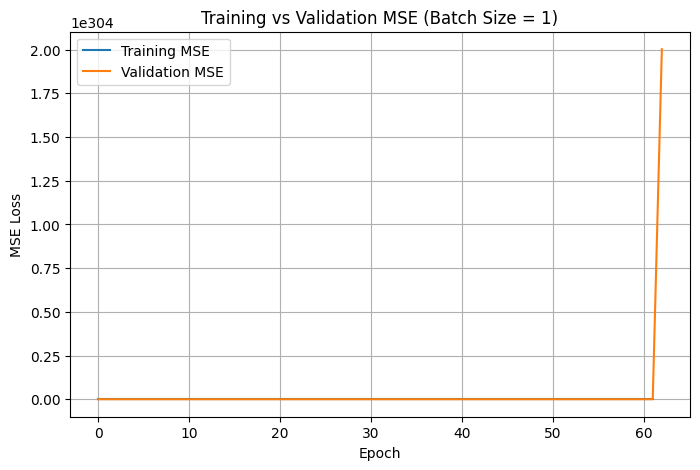

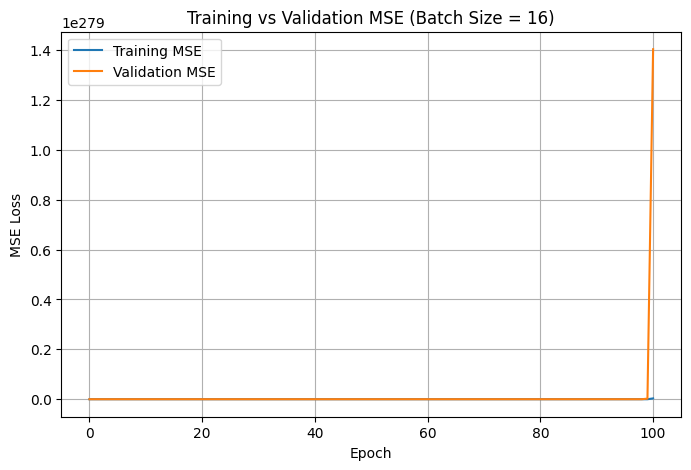

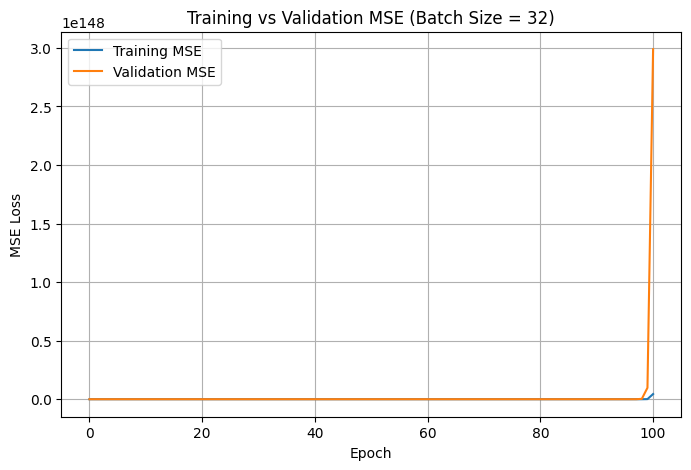

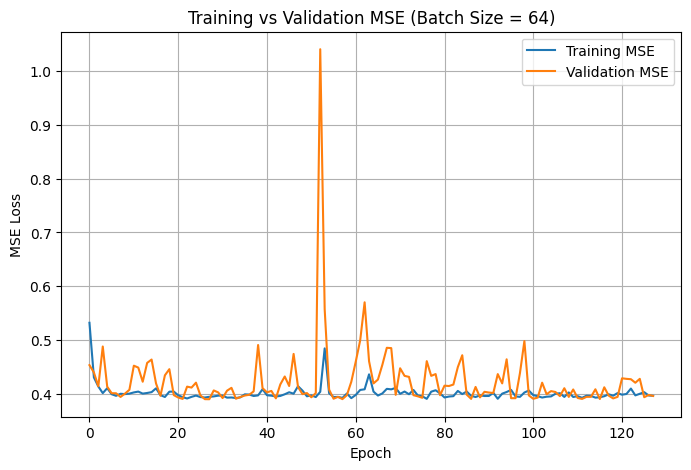

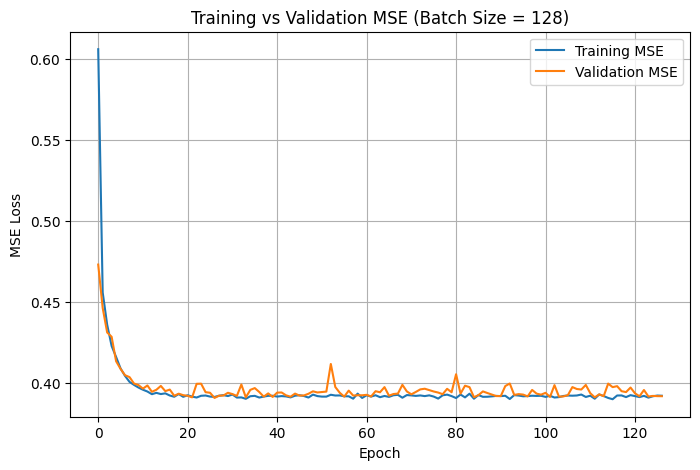

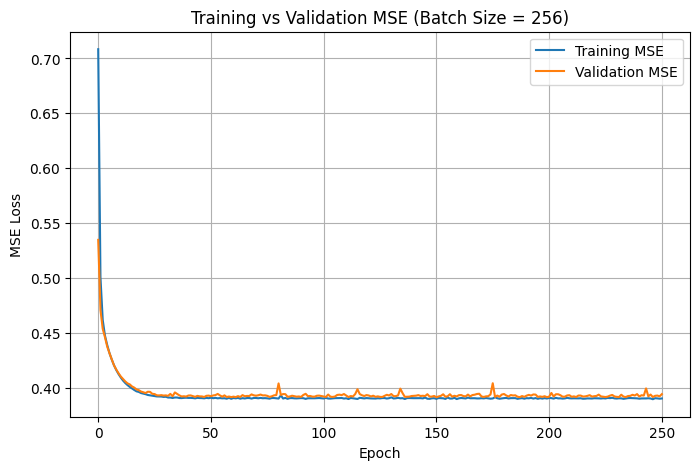

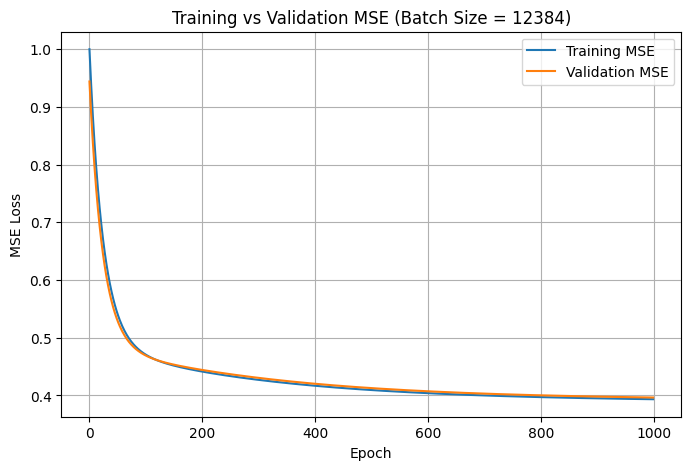

In [25]:
for batch_size in batch_sizes:

    result = batch_results[batch_size]

    plt.figure(figsize=(8, 5))

    plt.plot(
        result["train_loss"],
        label="Training MSE"
    )

    plt.plot(
        result["val_loss"],
        label="Validation MSE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"Training vs Validation MSE "
        f"(Batch Size = {batch_size})"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

#***Task 5: Inference on Test Set***

In [26]:
best_model_weights = batch_results[best_batch_size]["weights"]

In [27]:
train_pred_norm = X_train_final @ best_model_weights
val_pred_norm = X_val_final @ best_model_weights
test_pred_norm = X_test_final @ best_model_weights

In [28]:
train_pred = train_pred_norm * y_std + y_mean
val_pred = val_pred_norm * y_std + y_mean
test_pred = test_pred_norm * y_std + y_mean

In [29]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [30]:
def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

In [31]:
def mape(y_true, y_pred):
    return 100 * np.mean(
        np.abs((y_true - y_pred) / y_true)
    )

In [32]:
def r_squared(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [33]:
metrics_table = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],

    "RMSE": [
        rmse(y_train, train_pred),
        rmse(y_val, val_pred),
        rmse(y_test, test_pred)
    ],

    "MAPE (%)": [
        mape(y_train, train_pred),
        mape(y_val, val_pred),
        mape(y_test, test_pred)
    ],

    "MAE": [
        mae(y_train, train_pred),
        mae(y_val, val_pred),
        mae(y_test, test_pred)
    ],

    "R-squared": [
        r_squared(y_train, train_pred),
        r_squared(y_val, val_pred),
        r_squared(y_test, test_pred)
    ]
})

metrics_table

,Dataset,RMSE,MAPE (%),MAE,R-squared
0,Training,0.723081,31.526735,0.527556,0.609702
1,Validation,0.723043,31.369138,0.532311,0.595357
2,Test,0.730173,31.227239,0.531213,0.603821


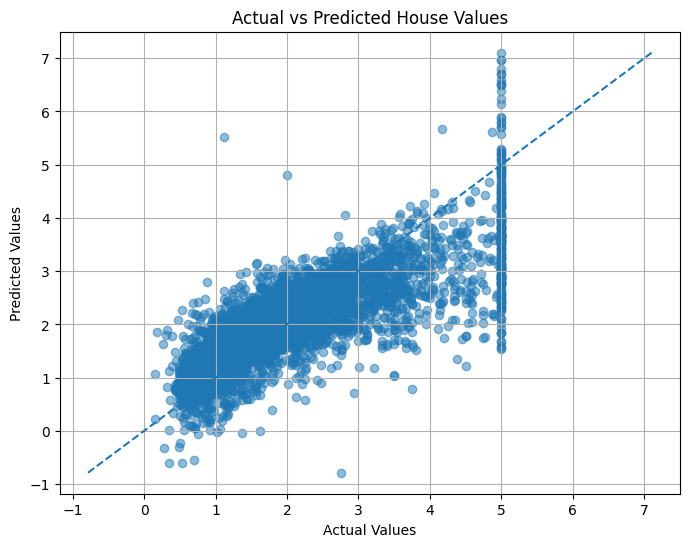

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    test_pred.min()
)

max_value = max(
    y_test.max(),
    test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.grid(True)
plt.show()